# Desincronización de Frecuencias en Series Temporales

El presente cuaderno de colab sirve de soporte al informe que desarrolla los conceptos contenidos.

Autor: [Martin Nicolas Serafini](https://www.linkedin.com/in/martin-nicolas-serafini-05224923b/)

## Librerias y funciones

In [ ]:
from requests import get
import numpy as np
import pandas as pd
import requests
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import os
import io
from google.colab import drive
from typing import List
import matplotlib.ticker as ticker

In [ ]:
def borrar_columnas(df_base, columnas_a_borrar):
    df = df_base.copy()
    df_limpio = df.drop(columns=columnas_a_borrar, errors='ignore')
    return df_limpio

## Banco Mundial - Evolucion poblacion Argentina

Datos 1960-2024: https://datos.bancomundial.org/indicador/SP.POP.TOTL?locations=AR

Dato 2025: https://www.worldometers.info/es/poblacion-mundial/poblacion-argentina/

In [ ]:
url = "https://raw.githubusercontent.com/MartinSerafini/Analisis_y_Mineria_de_Datos/main/003_comparacion_metodos_interpolacion/API_SP.POP.TOTL_DS2_es_csv_v2_92.csv"

# Cargo el DataFrame omitiendo las filas de metadatos iniciales del Banco Mundial
try:
    temp_df = pd.read_csv(url, skiprows=4)
    print("Dataset cargado correctamente desde GitHub.")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

In [ ]:
# Solo conservo los datos donde "Country Name" sea "Argentina"
temp_df = temp_df[temp_df['Country Name'] == 'Argentina']
cols_borrar = ['Country Name','Country Code','Indicator Name','Indicator Code']
temp_df = borrar_columnas(temp_df, cols_borrar)
temp_df = temp_df.T
temp_df.reset_index(inplace=True)
temp_df.columns = ['periodo','poblacion_argentina']


In [ ]:
temp_df['periodo'] = pd.to_numeric(temp_df['periodo'], errors='coerce')

In [ ]:
# Agrego el dato del periodo 2025 obtenido por fuera del Dataset del BM
temp_df.loc[len(temp_df)] = [2025, 45851378]
# Borro registros con datos null
temp_df = temp_df.dropna()

In [ ]:
# Genero una copia de trabajo y asigno el dato anual al mes 7 de cada año
df = temp_df.copy()

df = df.sort_values("periodo").reset_index(drop=True)
df["periodo"] = df["periodo"].astype(int)

df = df.groupby("periodo", as_index=False)["poblacion_argentina"].mean()

df["fecha"] = pd.to_datetime(df["periodo"].astype(str) + "-07-01")

df = df.set_index("fecha")

In [ ]:
# Genero el DF que va a albergar a los valores interpolados
idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="MS")

df_full = pd.DataFrame(index=idx)

df_full = df_full.merge(
    df[["poblacion_argentina"]],
    left_index=True,
    right_index=True,
    how="left"
)

In [ ]:
# Interpolacion Lineal
df_full["poblacion_lineal"] = df_full["poblacion_argentina"].interpolate(method="linear")

In [ ]:
# Interpolacion exponencial
df_full["poblacion_exponencial"] = np.nan

fechas = df.dropna().index

for i in range(len(fechas) - 1):
    f0 = fechas[i]
    f1 = fechas[i+1]

    # aseguro escalares
    P0_val = df.loc[f0, "poblacion_argentina"]
    P0 = P0_val.iloc[0] if isinstance(P0_val, pd.Series) else P0_val

    P1_val = df.loc[f1, "poblacion_argentina"]
    P1 = P1_val.iloc[0] if isinstance(P1_val, pd.Series) else P1_val

    r = np.log(P1 / P0)

    # tramo temporal
    mask = (df_full.index >= f0) & (df_full.index < f1)
    fechas_tramo = df_full.index[mask]

    n = len(fechas_tramo)

    if n == 0:
        continue

    frac = np.linspace(0, 1, n, endpoint=False)

    valores = P0 * np.exp(r * frac)

    df_full.loc[fechas_tramo, "poblacion_exponencial"] = valores

# ✔ Fuerzo las anclas (clave)
df_full.loc[df.index, "poblacion_exponencial"] = df["poblacion_argentina"]

In [ ]:
# Promedio Centrado
def suavizar_con_extremos(series, h=1):
    suavizada = series.copy()

    rolling = series.rolling(window=2*h+1, center=True).mean()

    # aplico solo donde hay ventana completa
    mask = rolling.notna()
    suavizada[mask] = rolling[mask]

    # ✔ mantengo extremos originales (primeros y últimos h valores)
    suavizada.iloc[:h] = series.iloc[:h]
    suavizada.iloc[-h:] = series.iloc[-h:]

    return suavizada

In [ ]:
# Genero los suavizados para ambos metodos
df_full["poblacion_lineal_suavizada_h1"] = suavizar_con_extremos(
    df_full["poblacion_lineal"], h=1
)

df_full["poblacion_exponencial_suavizada_h1"] = suavizar_con_extremos(
    df_full["poblacion_exponencial"], h=1
)

In [ ]:
# Mantengo anclajes en julio
df_full.loc[df.index, "poblacion_lineal_suavizada_h1"] = df["poblacion_argentina"]
df_full.loc[df.index, "poblacion_exponencial_suavizada_h1"] = df["poblacion_argentina"]

In [ ]:
df_all = df_full.reset_index().rename(columns={"index": "periodo"})
df_all["poblacion_argentina"] = df_all["poblacion_argentina"].ffill()

## Graficas

In [ ]:
# Para no contaminar con los anclajes las graficas genero un DF que los quita
df_plot = df_all[
    (df_all["periodo"] >= "2023-07-01") &
    (df_all["periodo"] <= "2024-07-01")
].copy()

# elimino julios (mes 7)
df_plot = df_plot[df_plot["periodo"].dt.month != 7]

df_plot["dif_abs"] = (
    df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"]
)
df_plot["dif_abs_lineal"] = (
    df_plot["poblacion_lineal"] - df_plot["poblacion_lineal_suavizada_h1"]
)
df_plot["dif_abs_expo"] = (
    df_plot["poblacion_exponencial"] - df_plot["poblacion_exponencial_suavizada_h1"]
)

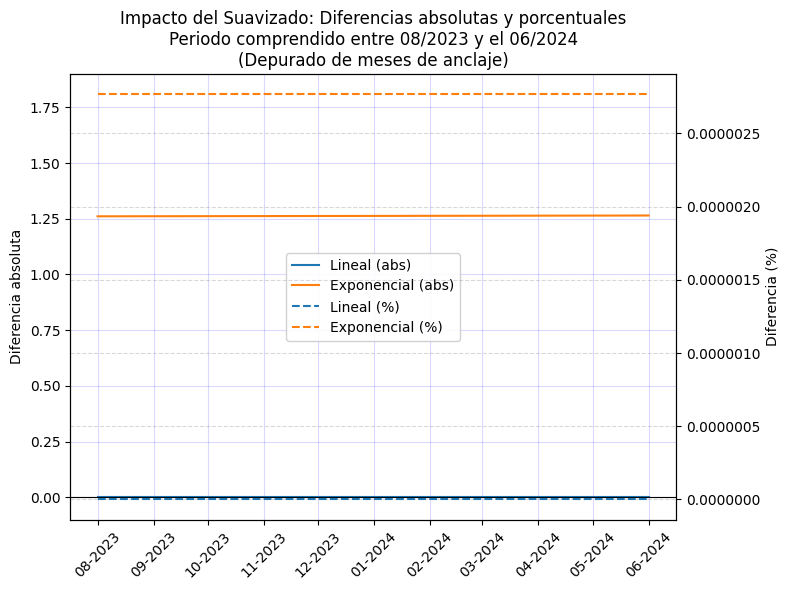

In [ ]:
df_plot = df_all[
    (df_all["periodo"] >= "2023-08-01") &
    (df_all["periodo"] <= "2024-06-01")
].copy()

# diferencias absolutas
df_plot["dif_lineal"] = (
    df_plot["poblacion_lineal_suavizada_h1"] - df_plot["poblacion_lineal"]
)

df_plot["dif_exp"] = (
    df_plot["poblacion_exponencial_suavizada_h1"] - df_plot["poblacion_exponencial"]
)

df_plot["dif_abs"] = (
    df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"]
)

# diferencias porcentuales
df_plot["dif_lineal_pct"] = (
    df_plot["dif_lineal"] / df_plot["poblacion_lineal"] * 100
)

df_plot["dif_exp_pct"] = (
    df_plot["dif_exp"] / df_plot["poblacion_exponencial"] * 100
)

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Eje Izquierdo (Absoluto) ---
l1, = ax1.plot(df_plot["periodo"], df_plot["dif_lineal"], label="Lineal (abs)")
l2, = ax1.plot(df_plot["periodo"], df_plot["dif_exp"], label="Exponencial (abs)")

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel("Diferencia absoluta")
ax1.set_ylim(-0.1, 1.9)

# Grid eje principal (Azul muy tenue por ejemplo)
ax1.grid(True, which='major', color='blue', linestyle='-', alpha=0.15)

# --- Eje Derecho (Porcentual) ---
ax2 = ax1.twinx()
l3, = ax2.plot(df_plot["periodo"], df_plot["dif_lineal_pct"], linestyle="--", label="Lineal (%)")
l4, = ax2.plot(df_plot["periodo"], df_plot["dif_exp_pct"], linestyle="--", label="Exponencial (%)")

ax2.set_ylabel("Diferencia (%)")

# 1. Grid eje secundario (Gris con menor opacidad)
ax2.grid(True, which='major', color='gray', linestyle='--', alpha=0.3)

# 2. Formatear eje derecho para evitar escala exponencial
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
ax2.ticklabel_format(style='plain', axis='y')

# --- Eje X ---
ax1.set_xticks(df_plot["periodo"])
ax1.set_xticklabels(df_plot["periodo"].dt.strftime("%m-%Y"), rotation=45)

# 3. Leyenda centrada en el cuadro
# Combinamos manejadores y etiquetas
lines = [l1, l2, l3, l4]
labels = [l.get_label() for l in lines]

# loc='center' y bbox_to_anchor=(0.5, 0.5) lo pone justo al medio de los ejes
ax1.legend(lines, labels, loc='center', bbox_to_anchor=(0.5, 0.5),
           framealpha=0.9) # framealpha ayuda a que se lea sobre el grid

plt.title("Impacto del Suavizado: Diferencias absolutas y porcentuales\nPeriodo comprendido entre 08/2023 y el 06/2024\n(Depurado de meses de anclaje)")
plt.tight_layout()
plt.show()

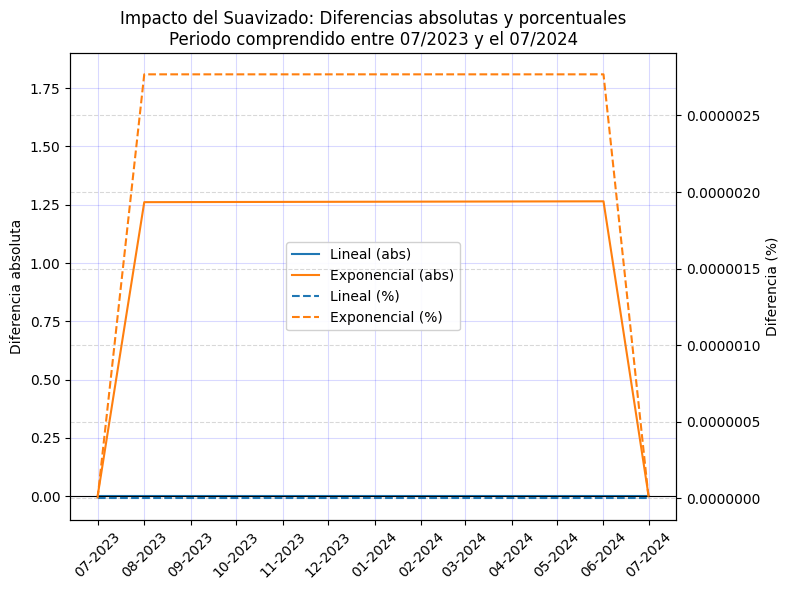

In [ ]:
#Incluyo meses de anclaje
df_plot = df_all[
    (df_all["periodo"] >= "2023-07-01") &
    (df_all["periodo"] <= "2024-07-01")
].copy()

# diferencias absolutas
df_plot["dif_lineal"] = (
    df_plot["poblacion_lineal_suavizada_h1"] - df_plot["poblacion_lineal"]
)

df_plot["dif_exp"] = (
    df_plot["poblacion_exponencial_suavizada_h1"] - df_plot["poblacion_exponencial"]
)

df_plot["dif_abs"] = (
    df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"]
)

# diferencias porcentuales
df_plot["dif_lineal_pct"] = (
    df_plot["dif_lineal"] / df_plot["poblacion_lineal"] * 100
)

df_plot["dif_exp_pct"] = (
    df_plot["dif_exp"] / df_plot["poblacion_exponencial"] * 100
)

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Eje Izquierdo (Absoluto) ---
l1, = ax1.plot(df_plot["periodo"], df_plot["dif_lineal"], label="Lineal (abs)")
l2, = ax1.plot(df_plot["periodo"], df_plot["dif_exp"], label="Exponencial (abs)")

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel("Diferencia absoluta")
ax1.set_ylim(-0.1, 1.9)

# Grid eje principal (Azul muy tenue por ejemplo)
ax1.grid(True, which='major', color='blue', linestyle='-', alpha=0.15)

# --- Eje Derecho (Porcentual) ---
ax2 = ax1.twinx()
l3, = ax2.plot(df_plot["periodo"], df_plot["dif_lineal_pct"], linestyle="--", label="Lineal (%)")
l4, = ax2.plot(df_plot["periodo"], df_plot["dif_exp_pct"], linestyle="--", label="Exponencial (%)")

ax2.set_ylabel("Diferencia (%)")

# 1. Grid eje secundario (Gris con menor opacidad)
ax2.grid(True, which='major', color='gray', linestyle='--', alpha=0.3)

# 2. Formatear eje derecho para evitar escala exponencial
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
ax2.ticklabel_format(style='plain', axis='y')

# --- Eje X ---
ax1.set_xticks(df_plot["periodo"])
ax1.set_xticklabels(df_plot["periodo"].dt.strftime("%m-%Y"), rotation=45)

# 3. Leyenda centrada en el cuadro
# Combinamos manejadores y etiquetas
lines = [l1, l2, l3, l4]
labels = [l.get_label() for l in lines]

# loc='center' y bbox_to_anchor=(0.5, 0.5) lo pone justo al medio de los ejes
ax1.legend(lines, labels, loc='center', bbox_to_anchor=(0.5, 0.5),
           framealpha=0.9) # framealpha ayuda a que se lea sobre el grid

plt.title("Impacto del Suavizado: Diferencias absolutas y porcentuales\nPeriodo comprendido entre 07/2023 y el 07/2024")
plt.tight_layout()
plt.show()

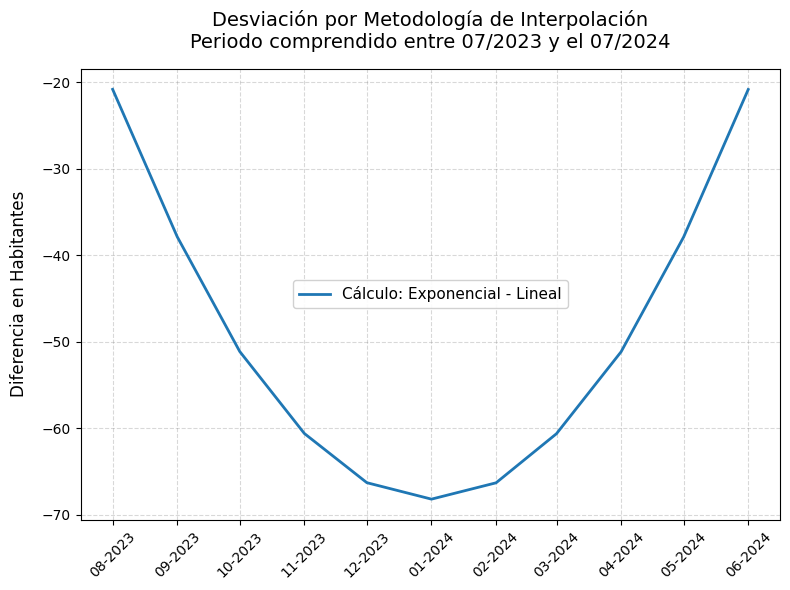

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Trazar la línea (Leyenda específica: qué estamos restando)
ax.plot(df_plot["periodo"], df_plot["dif_abs"],
        label="Cálculo: Exponencial - Lineal",
        color='#1f77b4', linewidth=2)

# --- ESTÉTICA ---
ax.grid(True, which='major', color='gray', linestyle='--', alpha=0.3)

# 2. Eje X (Fechas)
ax.set_xticks(df_plot["periodo"])
ax.set_xticklabels(df_plot["periodo"].dt.strftime("%m-%Y"), rotation=45)

# 3. Títulos y Etiquetas (Redactados para no ser redundantes)
ax.set_title("Desviación por Metodología de Interpolación\nPeriodo comprendido entre 07/2023 y el 07/2024", fontsize=14, pad=15)
ax.set_ylabel("Diferencia en Habitantes", labelpad=10, fontsize=12)

# Formateo de miles para que sea legible como "Habitantes"
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 4. Leyenda Centrada
ax.legend(loc='center', bbox_to_anchor=(0.5, 0.5),
          framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.show()

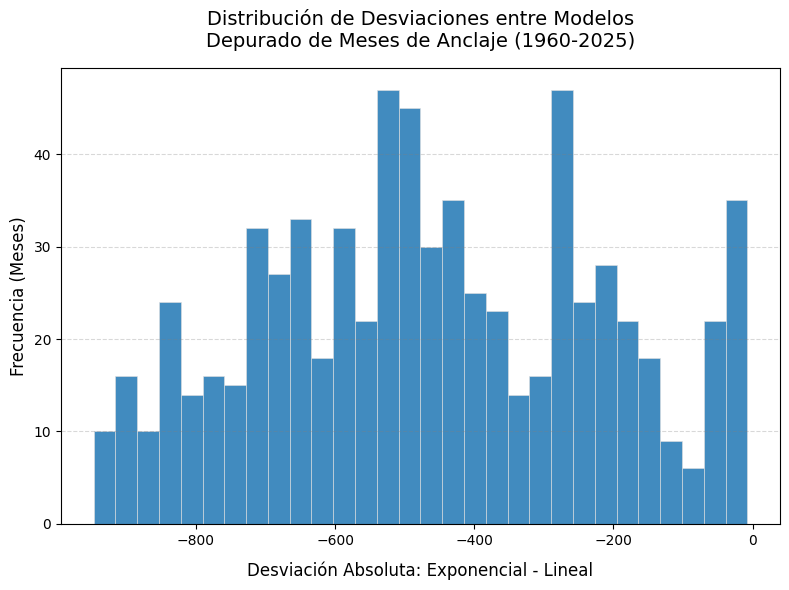

In [ ]:
df_plot = df_all.copy()

# Calculo la diferencia entre métodos
df_plot["dif_metodos"] = (
    df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"]
)
# Extraigo los meses 7 de cada año dado que son valores informados, asi no se confunden con coincidencias entre metodos
df_plot = df_plot[df_plot["periodo"].dt.month != 7]

# Creo la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 6)) # Usamos el mismo tamaño 10x6

# Genero el Histograma
n, bins, patches = ax.hist(df_plot["dif_metodos"], bins=30,
                            color='#1f77b4', edgecolor='#e0e0e0', linewidth=0.5,
                            alpha=0.85)

# Configuro el Grid
ax.grid(True, axis='y', which='major', color='gray', linestyle='--', alpha=0.3)

# Títulos y Etiquetas
ax.set_title("Distribución de Desviaciones entre Modelos\nDepurado de Meses de Anclaje (1960-2025)", fontsize=14, pad=15)
ax.set_ylabel("Frecuencia (Meses)", fontsize=12)
ax.set_xlabel("Desviación Absoluta: Exponencial - Lineal", labelpad=10, fontsize=12)

# Formato de Ejes con Separador de Miles
# Eje X: Diferencia de población
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
# Eje Y: Cantidad de meses
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualización
plt.tight_layout()
plt.show()

/tmp/ipykernel_4604/2742973747.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


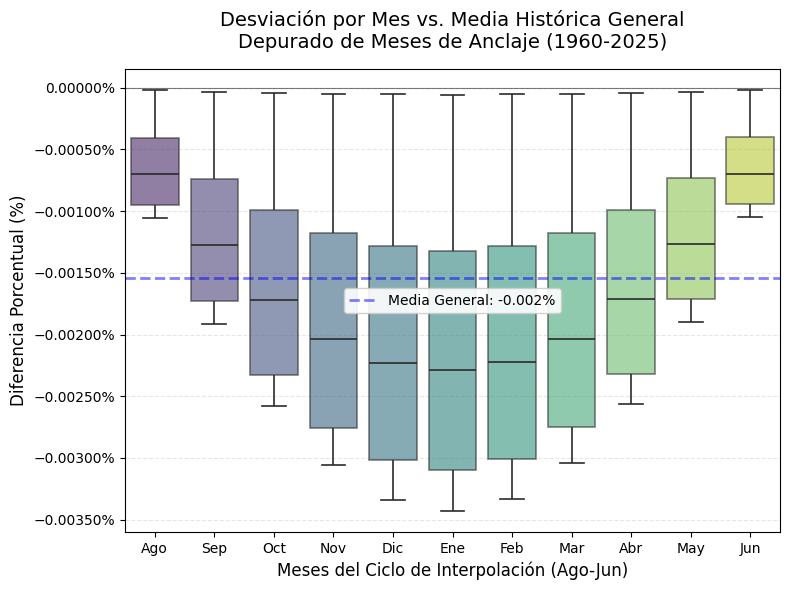

In [ ]:
# 1. Preparación de datos
df_pct = df_all.copy()
df_pct["dif_pct"] = (
    (df_pct["poblacion_exponencial"] - df_pct["poblacion_lineal"])
    / df_pct["poblacion_lineal"] * 100
)

# Filtramos julio y preparamos nombres
df_pct = df_pct[df_pct["periodo"].dt.month != 7].copy()
df_pct["n_mes"] = df_pct["periodo"].dt.month

meses_es = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}
df_pct["Mes"] = df_pct["n_mes"].map(meses_es)

orden_ciclo = ["Ago", "Sep", "Oct", "Nov", "Dic", "Ene", "Feb", "Mar", "Abr", "May", "Jun"]

# 2. Cálculo de la Media General (de todos los meses interpolados)
media_general = df_pct["dif_pct"].mean()

# 3. Configuración del gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Boxplot base
sns.boxplot(
    data=df_pct,
    x="Mes",
    y="dif_pct",
    order=orden_ciclo,
    palette="viridis",
    ax=ax,
    linewidth=1.2,
    fliersize=2,
    boxprops=dict(alpha=0.6)
)

# Línea Horizontal de Media General
ax.axhline(
    media_general,
    color='blue',
    linestyle='--',
    linewidth=2,
    alpha=0.5,
    label=f'Media General: {media_general:.3f}%'
)

# --- ESTÉTICA UNIFORME ---
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Línea de coincidencia total

ax.set_title("Desviación por Mes vs. Media Histórica General\nDepurado de Meses de Anclaje (1960-2025)", fontsize=14, pad=15)
ax.set_xlabel("Meses del Ciclo de Interpolación (Ago-Jun)", fontsize=12)
ax.set_ylabel("Diferencia Porcentual (%)", fontsize=12)

# Referencia centrada
ax.legend(loc='center', bbox_to_anchor=(0.5, 0.5), framealpha=0.9)

# Formatear el eje Y
ax.yaxis.set_major_formatter(ticker.PercentFormatter())

plt.tight_layout()
plt.show()

In [ ]:
df_plot = df_all.copy()

# Calculo la columna de diferencias %
df_plot["dif_pct"] = (
    (df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"])
    / df_plot["poblacion_lineal"] * 100
)

# Filtro los meses de anclaje
df_plot = df_plot[df_plot["periodo"].dt.month != 7].copy()

media = df_plot["dif_pct"].mean()

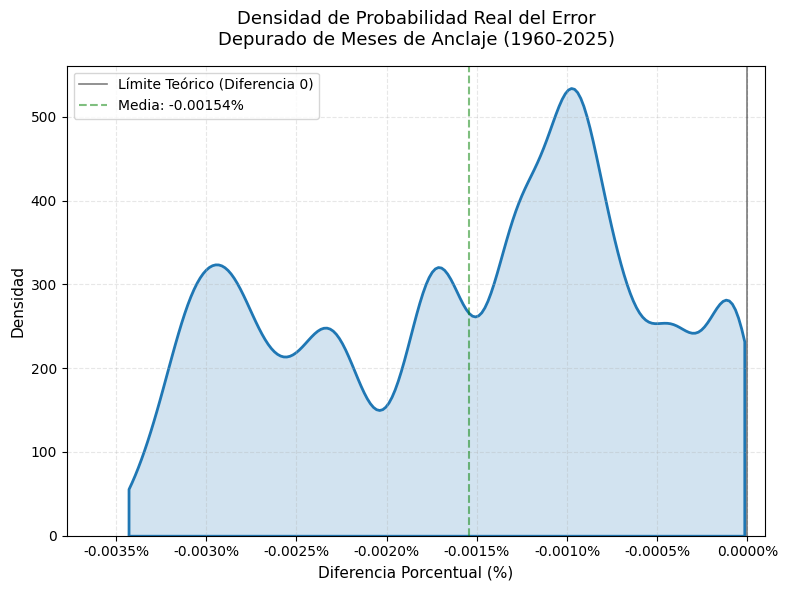

In [ ]:
# Datos
df_plot = df_all.copy()
df_plot["dif_pct"] = ((df_plot["poblacion_exponencial"] - df_plot["poblacion_lineal"]) / df_plot["poblacion_lineal"] * 100)
df_plot = df_plot[df_plot["periodo"].dt.month != 7].copy()

media = df_plot["dif_pct"].mean()

fig, ax = plt.subplots(figsize=(8, 6))

# KDE con CORRECCIÓN DE LÍMITES (cut=0)
sns.kdeplot(
    data=df_plot,
    x="dif_pct",
    fill=True,
    color='#1f77b4',
    alpha=0.2,
    linewidth=2,
    cut=0,      # Evito que prolongue la curva al lado positivo (tiende a generar una campana de gauss)
    bw_adjust=0.5, # Ajusto el suavizado para que sea más fiel a los picos reales
    ax=ax
)

# Líneas de referencia
ax.axvline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.5, label="Límite Teórico (Diferencia 0)")
ax.axvline(media, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label=f"Media: {media:.5f}%")

# Ajuste escala X
ax.set_xlim(df_plot["dif_pct"].min() * 1.1, 0.0001)

ax.set_title("Densidad de Probabilidad Real del Error\nDepurado de Meses de Anclaje (1960-2025)", fontsize=13, pad=15)
ax.set_xlabel("Diferencia Porcentual (%)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f%%'))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

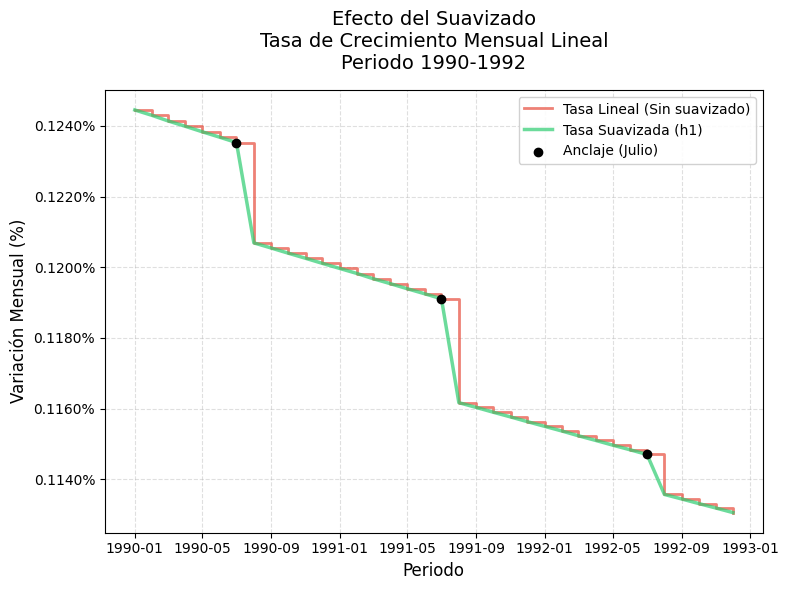

In [ ]:
# 1. Preparación de los datos
df_tasa = df_all.copy()
df_tasa['periodo'] = pd.to_datetime(df_tasa['periodo'])
df_tasa = df_tasa.sort_values('periodo')

# 2. Calcular la Tasa de Variación Mensual (%)
# Comparamos el método Lineal puro vs el Suavizado (h1)
df_tasa['tasa_lineal'] = df_tasa['poblacion_lineal'].pct_change() * 100
df_tasa['tasa_suavizada'] = df_tasa['poblacion_lineal_suavizada_h1'].pct_change() * 100

# 3. Seleccionar un periodo de ventana para ver el "salto" de Julio
# Elegimos 5 años para apreciar la "escalera"
mask = (df_tasa['periodo'] >= '1990-01-01') & (df_tasa['periodo'] <= '1992-12-01')
df_zoom = df_tasa.loc[mask]

# 4. Configuración del gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Trazar la tasa lineal (se verá como una escalera/serrucho)
ax.step(df_zoom['periodo'], df_zoom['tasa_lineal'], where='post',
        label='Tasa Lineal (Sin suavizado)', color='#e74c3c', alpha=0.7, linewidth=2)

# Trazar la tasa suavizada (se verá como una curva fluida)
ax.plot(df_zoom['periodo'], df_zoom['tasa_suavizada'],
        label='Tasa Suavizada (h1)', color='#2ecc71', linewidth=2.5, alpha=0.7)

# Marcar los meses de Julio (Datos oficiales)
julios = df_zoom[df_zoom['periodo'].dt.month == 7]
ax.scatter(julios['periodo'], julios['tasa_lineal'], color='black', zorder=5, label='Anclaje (Julio)')

# --- ESTÉTICA TÉCNICA ---
ax.set_title("Efecto del Suavizado\nTasa de Crecimiento Mensual Lineal\nPeriodo 1990-1992", fontsize=14, pad=15)
ax.set_ylabel("Variación Mensual (%)", fontsize=12)
ax.set_xlabel("Periodo", fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', framealpha=0.9)

# Formatear eje Y como porcentaje
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f%%'))

plt.tight_layout()
plt.show()

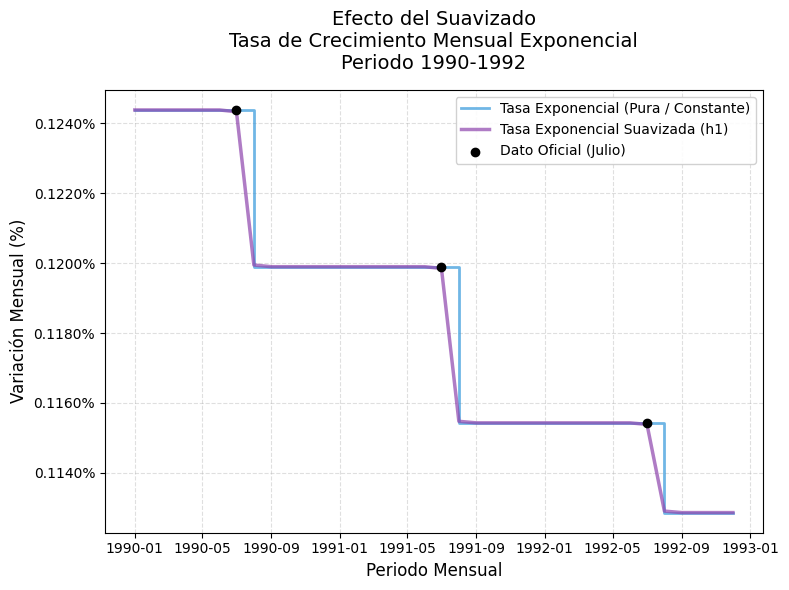

In [ ]:
# 1. Preparación de datos (Calculamos tasas para el modelo exponencial)
df_exp = df_all.copy()
df_exp['periodo'] = pd.to_datetime(df_exp['periodo'])
df_exp = df_exp.sort_values('periodo')

# Cálculo de tasas mensuales (%)
df_exp['tasa_exp_pura'] = df_exp['poblacion_exponencial'].pct_change() * 100
df_exp['tasa_exp_suavizada'] = df_exp['poblacion_exponencial_suavizada_h1'].pct_change() * 100

# 2. Zoom a un periodo de 5 años para notar la diferencia técnica
mask = (df_exp['periodo'] >= '1990-01-01') & (df_exp['periodo'] <= '1992-12-01')
df_zoom = df_exp.loc[mask]

# 3. Configuración del gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Tasa Exponencial Pura (Escalones perfectos)
# Usamos 'step' para enfatizar que la tasa es constante todo el año y salta en julio
ax.step(df_zoom['periodo'], df_zoom['tasa_exp_pura'], where='post',
        label='Tasa Exponencial (Pura / Constante)', color='#3498db', linewidth=2, alpha=0.7)

# Tasa Exponencial Suavizada (La transición orgánica)
ax.plot(df_zoom['periodo'], df_zoom['tasa_exp_suavizada'],
        label='Tasa Exponencial Suavizada (h1)', color='#8e44ad', linewidth=2.5, alpha=0.7)

# Puntos de anclaje de Julio
julios = df_zoom[df_zoom['periodo'].dt.month == 7]
ax.scatter(julios['periodo'], julios['tasa_exp_pura'], color='black', zorder=5, label='Dato Oficial (Julio)')

# --- ESTÉTICA PROFESIONAL ---
ax.set_title("Efecto del Suavizado\nTasa de Crecimiento Mensual Exponencial\nPeriodo 1990-1992", fontsize=14, pad=15)
ax.set_ylabel("Variación Mensual (%)", fontsize=12)
ax.set_xlabel("Periodo Mensual", fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', framealpha=0.9)

# Formatear eje Y con alta precisión (clave en tasas demográficas)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f%%'))

plt.tight_layout()
plt.show()

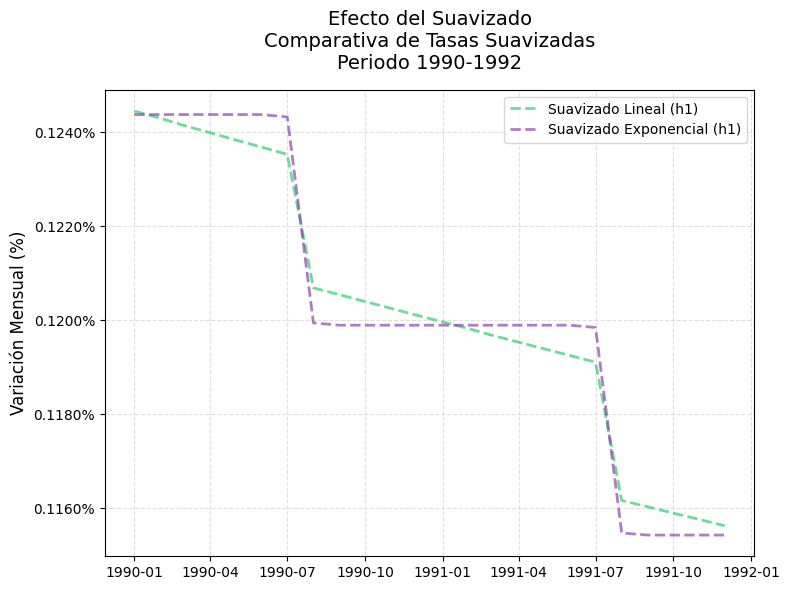

In [ ]:
# 1. Preparación de datos (Calculamos tasas entre modelos suavizados)
df_comp = df_all.copy()
df_comp['periodo'] = pd.to_datetime(df_comp['periodo'])
df_comp = df_comp.sort_values('periodo')

# Cálculo de tasas para los dos modelos suavizados
df_comp['tasa_lin_suave'] = df_comp['poblacion_lineal_suavizada_h1'].pct_change() * 100
df_comp['tasa_exp_suave'] = df_comp['poblacion_exponencial_suavizada_h1'].pct_change() * 100

# 2. Zoom a un periodo (1990-1995 para consistencia)
df_zoom = df_comp.loc[(df_comp['periodo'] >= '1990-01-01') & (df_comp['periodo'] <= '1991-12-01')]

# 3. Gráfico
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_zoom['periodo'], df_zoom['tasa_lin_suave'],
        label='Suavizado Lineal (h1)', color='#2ecc71', linewidth=2,linestyle='--',alpha=0.7)

ax.plot(df_zoom['periodo'], df_zoom['tasa_exp_suave'],
        label='Suavizado Exponencial (h1)', color='#8e44ad', linewidth=2, linestyle='--',alpha=0.7)

# --- ESTÉTICA ---
ax.set_title("Efecto del Suavizado\nComparativa de Tasas Suavizadas\nPeriodo 1990-1992", fontsize=14, pad=15)
ax.set_ylabel("Variación Mensual (%)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f%%'))

plt.tight_layout()
plt.show()